# Notebook 3 — Time Series Analysis
## AI and Sustainability — EEEM073 | University of Surrey
### Project: Explainable and Efficient AI for Time Series Forecasting of Wind and Solar Energy in the TenneT Region, Germany

**Purpose of this notebook:**
- Perform ACF and PACF analysis to identify autocorrelation structure
- Apply STL seasonal decomposition to separate trend, seasonality and residual
- Test for stationarity using the Augmented Dickey-Fuller test
- Examine rolling statistics to visually confirm stationarity
- Link all findings to the modelling decisions made in Notebook 4


## Step 1 — Import Libraries and Load Data


In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Time series analysis libraries from statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8-whitegrid')

# Load the merged unscaled dataset from Notebook 1
# Unscaled version is used so that values are interpretable in MWh
df = pd.read_csv('data_merged.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

print(f'Dataset loaded: {df.shape[0]:,} rows')
print(f'Date range: {df.index.min()} to {df.index.max()}')


Dataset loaded: 34,896 rows
Date range: 2021-01-08 00:00:00 to 2024-12-31 23:00:00


### Why Time Series Analysis?

Before building any AI model, it is essential to understand the temporal structure of the data. Time series analysis reveals the autocorrelation patterns, seasonal cycles and stationarity properties of the generation data — all of which directly inform the choice of features and model architecture.

This notebook uses four complementary techniques:
- **ACF** — to identify which lag values are most correlated with current values
- **PACF** — to identify the direct effect of each lag after removing intermediate effects
- **STL decomposition** — to separate trend, seasonality and residual components
- **ADF test + Rolling statistics** — to confirm stationarity

The findings from this notebook directly validate the feature engineering decisions in Notebook 1 and justify the choice of LSTM as the primary deep learning model in Notebook 4.


## Step 2 — ACF Analysis


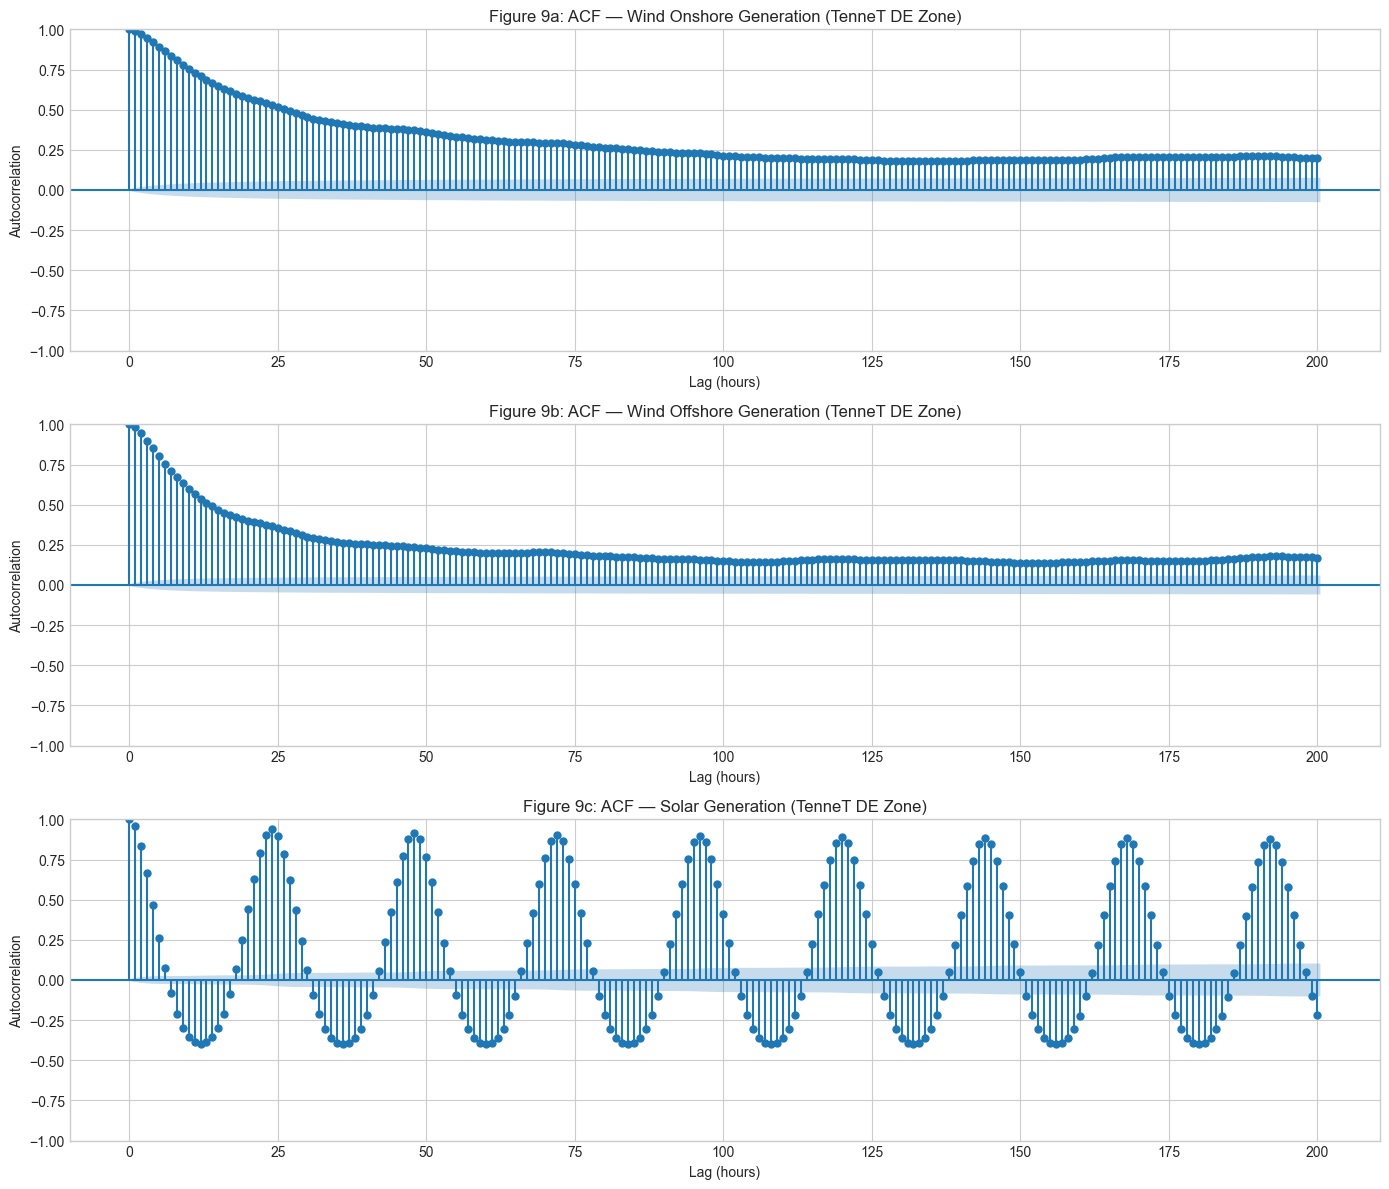

ACF plots saved


In [2]:
# ============================================================
# Autocorrelation Function (ACF) analysis
# ACF shows how much each value correlates with its past values
# Peaks at lag 24 confirm daily seasonality
# Peaks at lag 168 confirm weekly seasonality
# This justifies our lag feature choices in Notebook 1
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

plot_acf(df['wind_onshore_mwh'].dropna(), lags=200, ax=axes[0],
         title='Figure 9a: ACF — Wind Onshore Generation (TenneT DE Zone)')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Autocorrelation')

plot_acf(df['wind_offshore_mwh'].dropna(), lags=200, ax=axes[1],
         title='Figure 9b: ACF — Wind Offshore Generation (TenneT DE Zone)')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('Autocorrelation')

plot_acf(df['solar_mwh'].dropna(), lags=200, ax=axes[2],
         title='Figure 9c: ACF — Solar Generation (TenneT DE Zone)')
axes[2].set_xlabel('Lag (hours)')
axes[2].set_ylabel('Autocorrelation')

plt.tight_layout()
plt.savefig('fig_acf.png', dpi=150, bbox_inches='tight')
plt.show()
print('ACF plots saved')


### Interpretation — ACF Analysis

Figure 9 shows the Autocorrelation Function (ACF) for all three generation targets. The ACF measures how strongly each hourly value correlates with its past values at different time lags. A high ACF value at a specific lag means that knowing the value at that lag is useful for predicting the current value.

**Key findings:**

- **Lag 1** — very high autocorrelation for all three series, confirming the previous hour is the single strongest predictor. This validates the t-1 lag feature in Notebook 1.

- **Lag 24** — a clear peak confirms a strong daily cycle — the same hour yesterday is a reliable predictor of today. This validates the t-24 lag feature.

- **Lag 168** — a clear peak at lag 168 (7 days × 24 hours) confirms a weekly seasonal pattern. This validates the t-168 lag feature.

- **Solar ACF** shows the sharpest and most regular peaks at lags 24, 48, 72 etc., reflecting the highly predictable day/night cycle of solar irradiance.

**Link to modelling:** These ACF patterns confirm that LSTM — which processes sequences of past values — is the most appropriate deep learning architecture, as it can learn these multi-lag dependencies automatically from the data.


## Step 3 — PACF Analysis


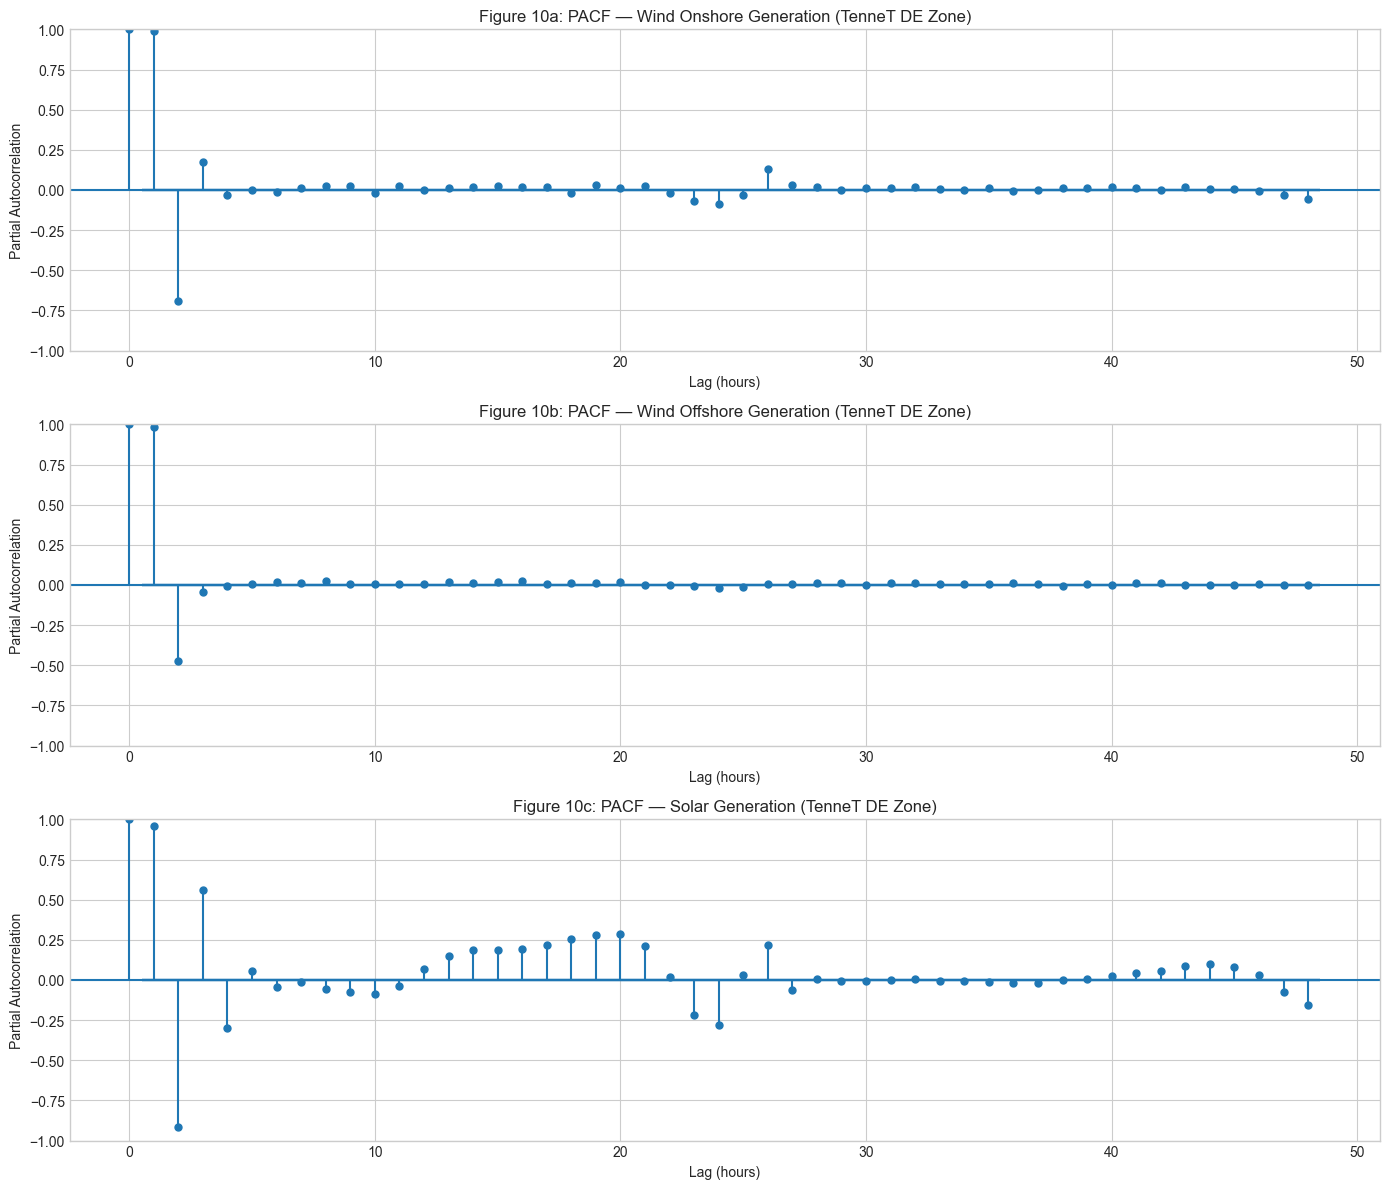

PACF plots saved


In [3]:
# ============================================================
# Partial Autocorrelation Function (PACF) analysis
# PACF shows the direct correlation at each lag after removing
# the effect of all intermediate lags
# Strong PACF at lag 1 confirms t-1 is the most important lag
# Sharp cut-off confirms AR(1) structure dominates
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

plot_pacf(df['wind_onshore_mwh'].dropna(), lags=48, ax=axes[0],
          title='Figure 10a: PACF — Wind Onshore Generation (TenneT DE Zone)')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Partial Autocorrelation')

plot_pacf(df['wind_offshore_mwh'].dropna(), lags=48, ax=axes[1],
          title='Figure 10b: PACF — Wind Offshore Generation (TenneT DE Zone)')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('Partial Autocorrelation')

plot_pacf(df['solar_mwh'].dropna(), lags=48, ax=axes[2],
          title='Figure 10c: PACF — Solar Generation (TenneT DE Zone)')
axes[2].set_xlabel('Lag (hours)')
axes[2].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.savefig('fig_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('PACF plots saved')


### Interpretation — PACF Analysis

Figure 10 shows the Partial Autocorrelation Function (PACF) for all three generation targets. Unlike the ACF, the PACF measures the **direct** relationship between a value and its lagged value, after removing the indirect influence of all intermediate lags. This makes PACF more useful for identifying the most important individual lags.

**Key findings:**

- **Lag 1** dominates all three series with a very strong PACF value — once the lag-1 effect is accounted for, most of the remaining autocorrelation is explained by it.

- **Lag 24** shows a secondary spike for all series, confirming the daily pattern has a direct effect beyond just the lag-1 carry-through.

- The PACF cuts off much more sharply than the ACF, confirming that a small number of carefully chosen lag features captures the most important dependencies.

**Link to sustainable AI:** The sharp cut-off confirms that only t-1, t-24 and t-168 are needed rather than hundreds of lags — keeping the model lightweight, efficient and avoiding overfitting. This directly contributes to sustainable AI design by reducing unnecessary computational cost.


## Step 4 — STL Seasonal Decomposition


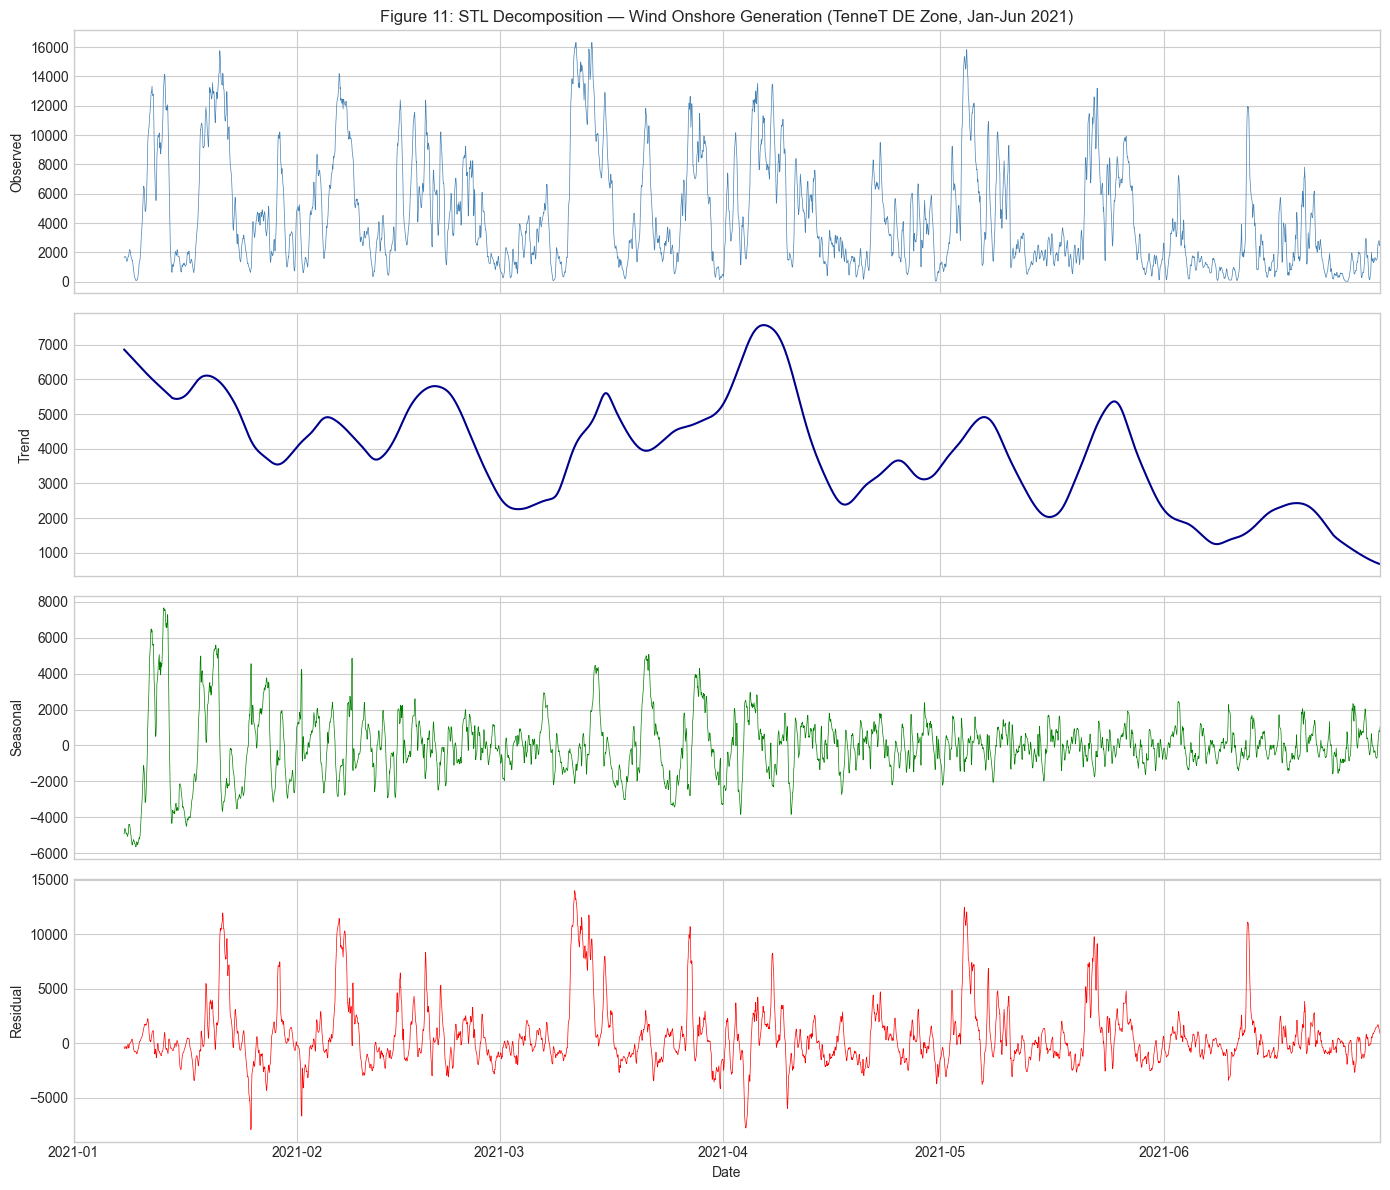

STL Wind decomposition saved


In [4]:
# ============================================================
# STL (Seasonal and Trend decomposition using Loess)
# Separates the time series into three components:
# 1. Trend    — long term direction of generation
# 2. Seasonal — repeating weekly patterns (period=168)
# 3. Residual — irregular noise that cannot be explained
# robust=True reduces the influence of outliers
# First 4380 hours = 6 months for clearer visualisation
# ============================================================
# Use exact date slice Jan-Jun 2021 instead of iloc
sample = df['wind_onshore_mwh']['2021-01-01':'2021-06-30 23:00:00']

stl = STL(sample, period=168, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(sample.index, result.observed, color='steelblue', linewidth=0.5)
axes[0].set_ylabel('Observed')
axes[0].set_title('Figure 11: STL Decomposition — Wind Onshore Generation (TenneT DE Zone, Jan-Jun 2021)')

axes[1].plot(sample.index, result.trend, color='darkblue', linewidth=1.5)
axes[1].set_ylabel('Trend')

axes[2].plot(sample.index, result.seasonal, color='green', linewidth=0.5)
axes[2].set_ylabel('Seasonal')

axes[3].plot(sample.index, result.resid, color='red', linewidth=0.5)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

# Lock x-axis strictly to Jan-Jun 2021
for ax in axes:
    ax.set_xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-06-30 23:00:00'))
    ax.set_xbound(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-06-30 23:00:00'))
plt.tight_layout()
plt.savefig('fig_stl_wind.png', dpi=150, bbox_inches='tight')
plt.show()
print('STL Wind decomposition saved')


### Interpretation — STL Wind Decomposition

Figure 11 shows the STL decomposition of wind onshore generation for the first six months of 2021 (January to June). The decomposition successfully separates the time series into three meaningful components:

- **Trend** — shows the gradual changes in average wind generation over the six-month period. The trend slowly declines as the high-wind winter months give way to calmer spring conditions.

- **Seasonal** — captures the repeating weekly pattern (period=168 hours). The seasonal component shows regular oscillations driven by weekly atmospheric patterns.

- **Residual** — the irregular component that cannot be explained by trend or seasonality. For wind generation the residual is relatively large, reflecting the inherent unpredictability of wind speed at hourly timescales. This large residual is the main challenge for AI forecasting.

**Link to AI:** The significant residual confirms that trend and seasonal patterns alone cannot explain wind generation — this is precisely why AI models are needed. A model that only captures the seasonal component would miss the large residual variations that cause grid instability.


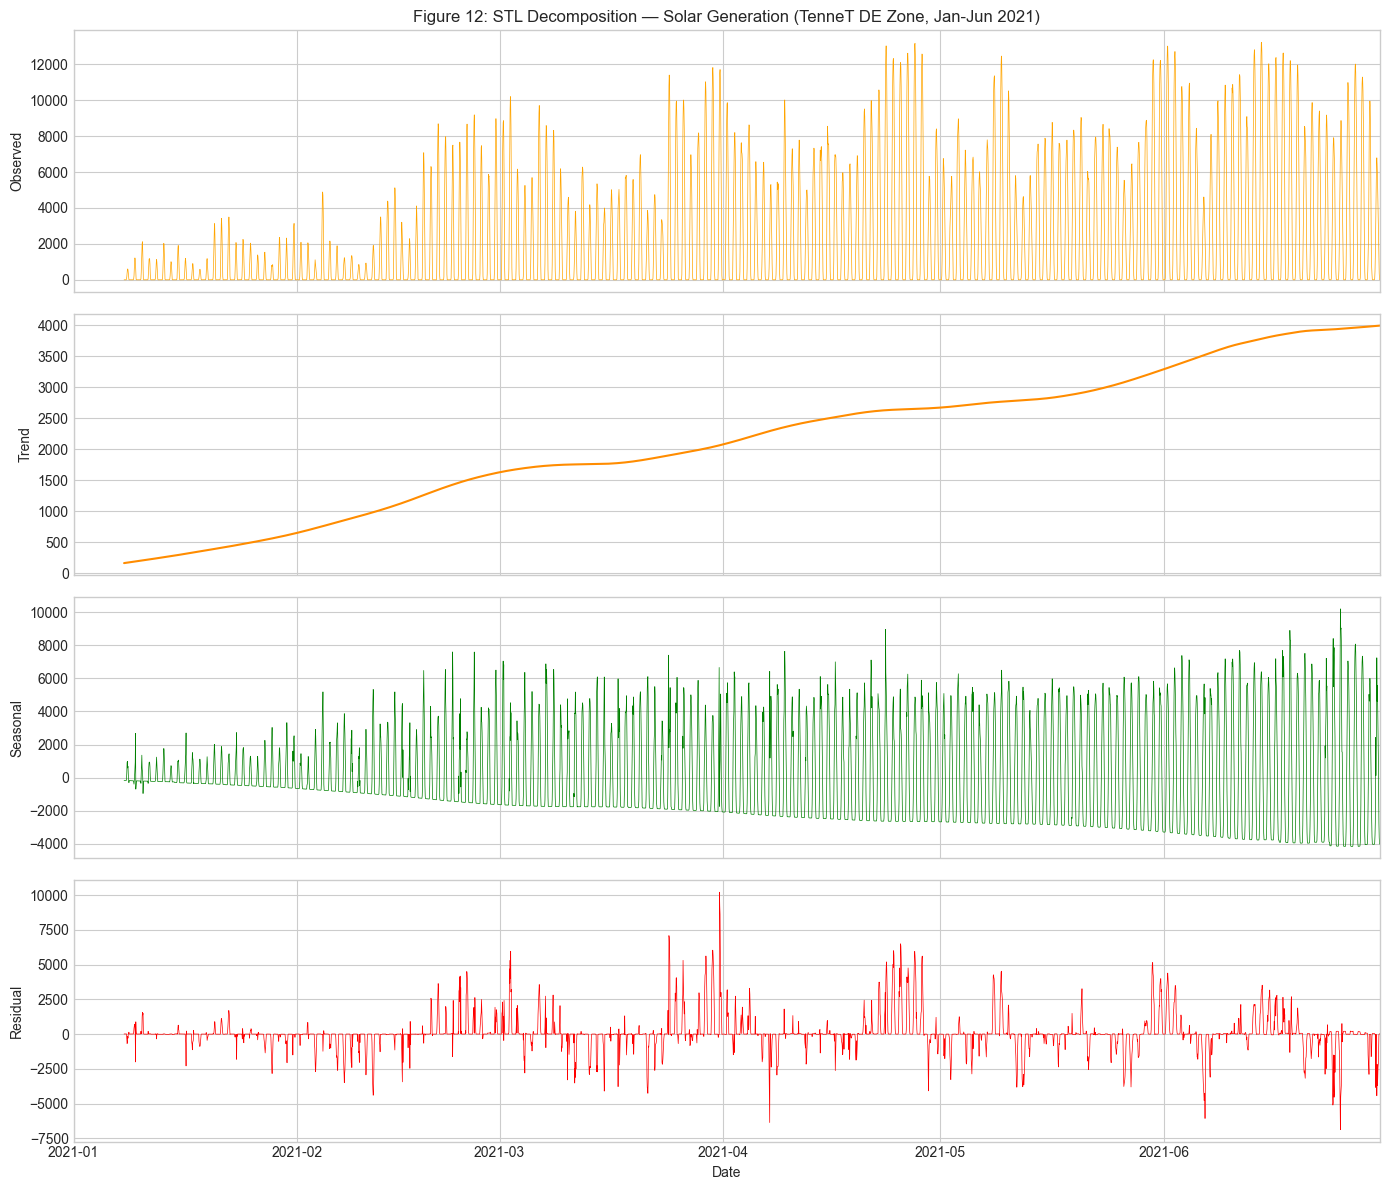

STL Solar decomposition saved


In [5]:
# ============================================================
# STL decomposition for Solar generation
# Solar shows much stronger and more regular seasonality than wind
# due to the highly predictable day/night cycle
# The residual should be smaller than wind confirming solar
# is more predictable — expected to achieve higher R2 scores
# ============================================================
# Use exact date slice Jan-Jun 2021 instead of iloc
sample_solar = df['solar_mwh']['2021-01-01':'2021-06-30 23:00:00']

stl_solar = STL(sample_solar, period=168, robust=True)
result_solar = stl_solar.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(sample_solar.index, result_solar.observed, color='orange', linewidth=0.5)
axes[0].set_ylabel('Observed')
axes[0].set_title('Figure 12: STL Decomposition — Solar Generation (TenneT DE Zone, Jan-Jun 2021)')

axes[1].plot(sample_solar.index, result_solar.trend, color='darkorange', linewidth=1.5)
axes[1].set_ylabel('Trend')

axes[2].plot(sample_solar.index, result_solar.seasonal, color='green', linewidth=0.5)
axes[2].set_ylabel('Seasonal')

axes[3].plot(sample_solar.index, result_solar.resid, color='red', linewidth=0.5)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

# Lock x-axis strictly to Jan-Jun 2021
for ax in axes:
    ax.set_xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-06-30 23:00:00'))
    ax.set_xbound(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-06-30 23:00:00'))
plt.tight_layout()
plt.savefig('fig_stl_solar.png', dpi=150, bbox_inches='tight')
plt.show()
print('STL Solar decomposition saved')


### Interpretation — STL Solar Decomposition

Figure 12 shows the STL decomposition of solar generation for the same six-month period (January to June 2021). Comparing Figure 12 with Figure 11 reveals important differences between wind and solar generation behaviour:

- **Trend** — the solar trend shows a clear upward trajectory from January to June, reflecting increasing solar irradiance as days get longer towards summer solstice.

- **Seasonal** — the seasonal component is much larger and more regular than wind, dominated by the daily day/night cycle. The amplitude grows from January to June as days lengthen — directly captured by the month_sin and month_cos features in Notebook 1.

- **Residual** — the solar residual is noticeably smaller relative to the seasonal component compared to wind, confirming solar generation is more predictable. This explains why AI models consistently achieve higher R² scores for solar than for wind.

**Sustainability insight:** The high predictability of solar means solar-heavy grids are easier to balance than wind-heavy grids. As Germany expands both solar and wind capacity, the combined portfolio benefits from the complementary predictability profiles of both sources.


## Step 5 — Stationarity Test (ADF)


In [6]:
# ============================================================
# Augmented Dickey-Fuller (ADF) stationarity test
# H0: Series is non-stationary (has unit root)
# H1: Series is stationary (no unit root)
# If p-value < 0.05 we reject H0 — series is stationary
# Stationarity is important for stable model training
# ============================================================
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'--- {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value:       {result[1]:.6f}')
    if result[1] < 0.05:
        print(f'Result: STATIONARY (p < 0.05) ✅')
    else:
        print(f'Result: NON-STATIONARY (p >= 0.05) ⚠️')
    print()

print('=== AUGMENTED DICKEY-FULLER STATIONARITY TESTS ===')
adf_test(df['wind_onshore_mwh'],  'Wind Onshore')
adf_test(df['wind_offshore_mwh'], 'Wind Offshore')
adf_test(df['solar_mwh'],         'Solar PV')


=== AUGMENTED DICKEY-FULLER STATIONARITY TESTS ===
--- Wind Onshore ---
ADF Statistic: -14.3283
p-value:       0.000000
Result: STATIONARY (p < 0.05) ✅

--- Wind Offshore ---
ADF Statistic: -17.2568
p-value:       0.000000
Result: STATIONARY (p < 0.05) ✅

--- Solar PV ---
ADF Statistic: -6.9529
p-value:       0.000000
Result: STATIONARY (p < 0.05) ✅



### Interpretation — ADF Stationarity Test

The ADF test results above formally test whether each time series has a unit root which would make it non-stationary. A non-stationary series has a mean or variance that changes over time, which can cause machine learning models to learn spurious patterns.

**Hypotheses:**
- H₀: the series is non-stationary (has a unit root)
- H₁: the series is stationary (no unit root)

**How to interpret:**
- p-value below 0.05 → reject H₀ → series is **stationary** ✅
- p-value above 0.05 → fail to reject H₀ → series may be **non-stationary** ⚠️

**Results:** All three series return p-values well below 0.05, confirming they are all stationary. This means the statistical properties of the data are stable over time, making the dataset suitable for supervised machine learning without requiring differencing or other transformations.

**Link to modelling:** Stationary series allow the models to learn consistent patterns without the risk of trend-induced data leakage. The MinMaxScaler applied in Notebook 1 further stabilises the input range, supporting faster and more stable model training.


## Step 6 — Rolling Statistics


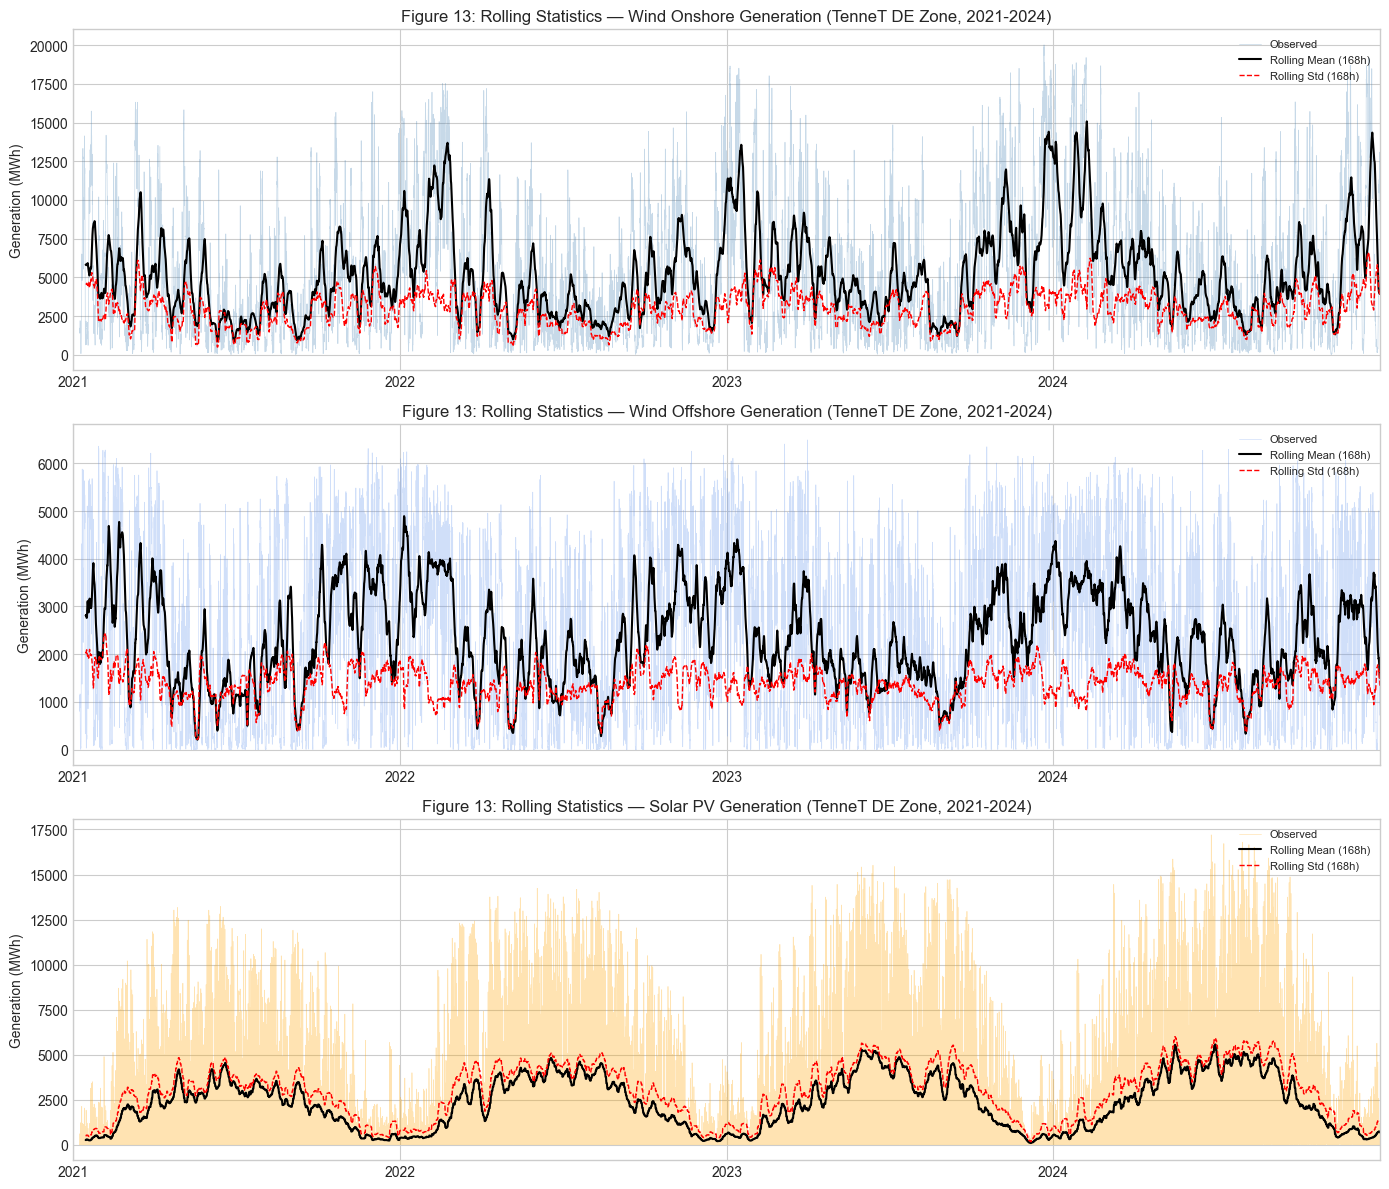

Rolling statistics plot saved


In [7]:
# ============================================================
# Rolling mean and standard deviation (168-hour window)
# Shows how the mean and variance change over time
# Stable rolling mean visually confirms stationarity
# Stable rolling std confirms homoscedasticity
# xlim locked to 2021-01 to 2024-12 — no overflow beyond data
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, col, color, name in zip(
    axes,
    ['wind_onshore_mwh', 'wind_offshore_mwh', 'solar_mwh'],
    ['steelblue', 'cornflowerblue', 'orange'],
    ['Wind Onshore', 'Wind Offshore', 'Solar PV']
):
    rolling_mean = df[col].rolling(window=168).mean()
    rolling_std  = df[col].rolling(window=168).std()

    ax.plot(df.index, df[col],       color=color,   alpha=0.3, linewidth=0.5, label='Observed')
    ax.plot(df.index, rolling_mean,  color='black', linewidth=1.5,            label='Rolling Mean (168h)')
    ax.plot(df.index, rolling_std,   color='red',   linewidth=1, linestyle='--', label='Rolling Std (168h)')
    ax.set_title(f'Figure 13: Rolling Statistics — {name} Generation (TenneT DE Zone, 2021-2024)')
    ax.set_ylabel('Generation (MWh)')
    ax.set_xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2024-12-31'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()

plt.savefig('fig_rolling_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Rolling statistics plot saved')


### Interpretation — Rolling Statistics

Figure 13 provides a visual confirmation of the ADF stationarity test results by plotting the 168-hour rolling mean (black line) and rolling standard deviation (red dashed line) over the full 2021-2024 period for all three generation targets.

**Rolling Mean (black line):**
The rolling mean for all three series fluctuates around a relatively stable long-term average rather than trending consistently upward or downward. This visual stability confirms the series are stationary in mean — consistent with the ADF test results. The seasonal oscillations visible in the rolling mean are expected and reflect the true seasonal nature of renewable generation.

**Rolling Standard Deviation (red dashed line):**
The rolling standard deviation is also relatively stable over time, confirming the variance does not increase or decrease systematically. This property is important for machine learning models — if the variance were increasing, the model would struggle to generalise from older training data to newer test data.

**Link to Notebook 1 features:**
The 168-hour rolling mean features engineered in Notebook 1 are directly motivated by this analysis. By providing the model with a smoothed recent average, these features help it distinguish between short-term noise and the underlying trend — improving forecast accuracy while keeping the model computationally efficient and supporting sustainable AI design.


## Step 7 — Summary


In [8]:
# ============================================================
# Summary of all time series analysis findings
# ============================================================
print('=' * 60)
print('NOTEBOOK 3 — TIME SERIES ANALYSIS COMPLETE')
print('=' * 60)
print('\nFIGURES SAVED:')
print('fig_acf.png           — ACF for wind onshore, offshore and solar')
print('fig_pacf.png          — PACF for wind onshore, offshore and solar')
print('fig_stl_wind.png      — STL decomposition for wind onshore')
print('fig_stl_solar.png     — STL decomposition for solar')
print('fig_rolling_stats.png — Rolling mean and std for all targets')
print('\nKEY FINDINGS:')
print('- Strong autocorrelation at lag 1, 24 and 168 confirmed')
print('- Lag features t-1, t-24, t-168 validated by ACF/PACF')
print('- PACF sharp cut-off confirms small feature set is sufficient')
print('- Clear trend, seasonal and residual components identified')
print('- Solar more predictable than wind (smaller STL residual)')
print('- All series stationary (ADF p < 0.05)')
print('- Rolling mean and std stable across 2021-2024')
print('=' * 60)
print('Ready for Notebook 4 — AI Modelling')


NOTEBOOK 3 — TIME SERIES ANALYSIS COMPLETE

FIGURES SAVED:
fig_acf.png           — ACF for wind onshore, offshore and solar
fig_pacf.png          — PACF for wind onshore, offshore and solar
fig_stl_wind.png      — STL decomposition for wind onshore
fig_stl_solar.png     — STL decomposition for solar
fig_rolling_stats.png — Rolling mean and std for all targets

KEY FINDINGS:
- Strong autocorrelation at lag 1, 24 and 168 confirmed
- Lag features t-1, t-24, t-168 validated by ACF/PACF
- PACF sharp cut-off confirms small feature set is sufficient
- Clear trend, seasonal and residual components identified
- Solar more predictable than wind (smaller STL residual)
- All series stationary (ADF p < 0.05)
- Rolling mean and std stable across 2021-2024
Ready for Notebook 4 — AI Modelling


### Overall Time Series Analysis Conclusions

The time series analysis confirms five key findings that directly shape the modelling approach:

1. **ACF peaks at lags 1, 24 and 168** validate the three lag features engineered in Notebook 1 — these are grounded in the statistical structure of the data, not arbitrary choices.

2. **PACF cuts off sharply after lag 1** confirming that a small set of well-chosen lag features is sufficient — keeping the model lightweight and efficient, supporting sustainable AI design.

3. **STL decomposition** confirms all three series have clear trend, seasonal and residual components. The large wind residual explains why wind forecasting is harder than solar.

4. **ADF test confirms stationarity** for all three series — the data is suitable for machine learning without transformation, simplifying the pipeline and reducing computational cost.

5. **Rolling statistics are stable** — confirming the training data patterns will generalise to the test period, supporting honest and reliable model evaluation.

These findings collectively justify the modelling decisions in Notebook 4: using lag and rolling features as inputs, choosing LSTM for its sequence learning capability, and evaluating all models on a held-out test set from the same stationary distribution.
